In [1]:

import os

# Pick physical GPU 2 before importing torch in this kernel session.
os.environ["CUDA_VISIBLE_DEVICES"] = "2"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

from glp.denoiser import load_glp
from glp import flow_matching, script_eval, script_steer
from glp.utils_acts import save_acts
from gemma2_pipeline.loading import iter_fineweb_texts, load_model_and_tokenizer
from gemma2_pipeline.preprocess import batch_items
from gemma2_pipeline.settings import FineWebSourceConfig

/mnt/disk2/envs/glp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

import torch

print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("Visible logical GPUs:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("Logical cuda:0:", torch.cuda.get_device_name(0))

CUDA_VISIBLE_DEVICES: 2
Visible logical GPUs: 1
Logical cuda:0: NVIDIA A30


**Load the GLP**

You can just put the HuggingFace repo and the checkpoint will be automatically downloaded for you.

In [3]:
# With CUDA_VISIBLE_DEVICES=2, physical GPU 2 is remapped to logical cuda:0.
device = "cuda:0"

# Your Gemma GLP checkpoint (local folder or HF repo id).
glp_name = "PQPQPQHUST/glp-gpt2-med"
glp_ckpt = "1B/ot_gauss/900M"

# Gemma LLM setup for streaming reference activations and steering.
hf_model = "openai-community/gpt2-medium"
hf_layer = 12
vector_path = "Vector/CAA/extracted/GPT2/med/vector.pt"

In [4]:
import time

t0 = time.time()
try:
    model, mean, var = load_glp(glp_name, device=device, checkpoint=glp_ckpt, local_files_only=True)
    print("Loaded GLP from local cache.")
except Exception as cache_err:
    print(f"Local cache miss ({type(cache_err).__name__}), falling back to online download.")
    model, mean, var = load_glp(glp_name, device=device, checkpoint=glp_ckpt, local_files_only=False)
model = model.to(torch.bfloat16)
model.eval()
embedding_dim = model.denoiser.model.d_input
print(f"GLP loaded in {time.time() - t0:.1f}s | embedding_dim={embedding_dim}")
print(f"Normalizer method: {getattr(model.normalizer, 'normalization_method', 'gaussian')}")

Loaded GLP from local cache.
GLP loaded in 2.1s | embedding_dim=1024
Normalizer method: gaussian


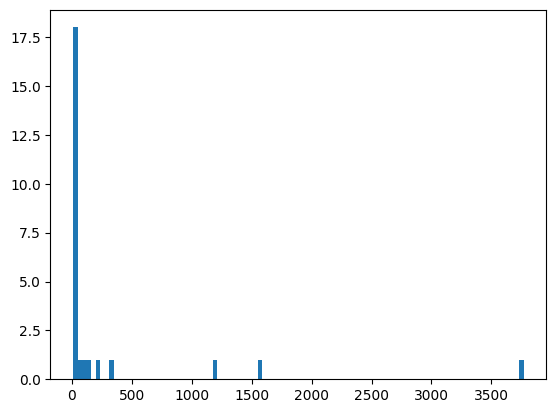

In [ ]:
plt.hist(var[var > 10].cpu().numpy(), bins=100)
plt.show()

**Checking GLP Quality**

Now that we've loaded up the model, we can sanity check that it's working by generating some activations.

In [5]:
def generate_activations(num_timesteps, batch_size, generator=None):
    print("Generating activations...")
    noise = torch.randn(batch_size, 1, embedding_dim, generator=generator).to(device)
    gen_latents = flow_matching.sample(model, noise, num_timesteps=num_timesteps)
    # map normalized latents back to activation space (gaussian or log_norm inverse)
    gen_latents = model.normalizer.denormalize(gen_latents)
    return gen_latents


def stream_reference_activations(
    hf_model,
    hf_tokenizer,
    layer,
    num_vectors=20000,
    dataset_name="HuggingFaceFW/fineweb",
    dataset_config="sample-10BT",
    split="train",
    text_field="text",
    max_documents=None,
    document_batch_size=16,
    forward_batch_size=1,
    max_length=1024,
    drop_bos=True,
):
    tracedict_config = {
        "layer_prefix": "model.layers",
        "layers": [layer],
        "retain": "output",
    }
    fineweb_cfg = FineWebSourceConfig(
        dataset_name=dataset_name,
        dataset_config=dataset_config,
        split=split,
        text_field=text_field,
        streaming=True,
        max_documents=max_documents,
    )

    text_iter = iter_fineweb_texts(fineweb_cfg)
    chunks = []
    vectors_written = 0
    for text_batch in tqdm(
        batch_items(text_iter, document_batch_size),
        desc="Streaming FineWeb acts",
        dynamic_ncols=True,
    ):
        acts = save_acts(
            hf_model=hf_model,
            hf_tokenizer=hf_tokenizer,
            text=text_batch,
            tracedict_config=tracedict_config,
            padding_side="right",
            token_idx="all",
            batch_size=forward_batch_size,
            max_length=max_length,
        )
        vecs = acts[:, 0, :, :]
        if drop_bos and vecs.shape[1] > 1:
            vecs = vecs[:, 1:, :]
        vecs = vecs.reshape(-1, vecs.shape[-1])
        if vecs.shape[0] == 0:
            continue

        remaining = num_vectors - vectors_written
        vecs = vecs[:remaining]
        chunks.append(vecs.cpu())
        vectors_written += vecs.shape[0]
        if vectors_written >= num_vectors:
            break

    if vectors_written == 0:
        raise RuntimeError("No reference activations were collected from FineWeb streaming.")

    ref_latents = torch.cat(chunks, dim=0)[:, None, :]
    print(f"Collected {ref_latents.shape[0]} streamed reference vectors.")
    return ref_latents


    
def plot_pca(num_timesteps, batch_size, ref_latents, gen_latents):
    gen_latents = gen_latents[:, 0, :].detach().cpu()
    ref_latents = ref_latents[:, 0, :].detach().cpu()
    gen_latents = gen_latents[:batch_size, :]
    ref_latents = ref_latents[:batch_size, :]
    title = f"Num Timesteps: {num_timesteps}"
    print("Plotting PCA...")
    return script_eval.plot_pca(
        ref_latents,
        gen_latents,
        label_X="Real",
        label_Y="Generated",
        title=title,
        alpha=0.8,
        half_mask=num_timesteps >= 10,
    )

In [6]:
def compute_fd(ref_latents, gen_latents, generator=None):
    ref_vecs = ref_latents[:, 0, :].detach().cpu().float()
    gen_vecs = gen_latents[:, 0, :].detach().cpu().float()
    
    n = min(ref_vecs.shape[0], gen_vecs.shape[0])
    if n < 2:
        raise ValueError("Need at least 2 vectors per set to compute Frechet Distance.")
    
    # Compute FD(generated, reference)
    fd_gen_ref = script_eval.rep_fd(ref_vecs[:n].float().numpy(), gen_vecs[:n].float().numpy())
    
    # Generate noise samples from standard normal distribution
    if generator is None:
        generator = torch.Generator()
    noise_vecs = torch.randn(n, ref_vecs.shape[1], generator=generator).float()
    
    # Compute FD(noise, reference)
    fd_noise_ref = script_eval.rep_fd(ref_vecs[:n].float().numpy(), noise_vecs[:n].float().numpy())
    
    # Return normalized FD
    # Avoid division by zero
    if fd_noise_ref < 1e-8:
        return float('inf')
    return fd_gen_ref, fd_gen_ref / fd_noise_ref

In [7]:
from pathlib import Path

ref_num_vectors = 50000
ref_cache = Path(f"data/frechet-stream-{hf_model.split('/')[-1]}-layer{hf_layer}-{ref_num_vectors}.pt")

if ref_cache.exists():
    print(f"Loading cached streamed reference activations from {ref_cache}")
    ref_latents = torch.load(ref_cache)["activations"]
else:
    print("Loading Gemma model for streaming references...")
    hf_model, hf_tokenizer = load_model_and_tokenizer(
        model_name=hf_model,
        device=device,
        torch_dtype_name="bfloat16",
    )
    ref_latents = stream_reference_activations(
        hf_model=hf_model,
        hf_tokenizer=hf_tokenizer,
        layer=hf_layer,
        num_vectors=ref_num_vectors,
        dataset_name="HuggingFaceFW/fineweb",
        dataset_config="sample-10BT",
        split="train",
        text_field="text",
        document_batch_size=16,
        forward_batch_size=1,
        max_length=1024,
    ).float()
    ref_cache.parent.mkdir(parents=True, exist_ok=True)
    torch.save({"activations": ref_latents}, ref_cache)
    print(f"Saved streamed references to {ref_cache}")

Loading cached streamed reference activations from data/frechet-stream-gpt2-medium-layer12-50000.pt


Below, you will see PCA plots and Frechet Distance scores against streamed FineWeb references.

- Low Frechet Distance means generated activations are closer to the real reference distribution.
- High Frechet Distance means generated activations are farther from the reference distribution.

If streaming is slow, reduce ref_num_vectors or max_length in the previous cell.

In [8]:
# Keep these evaluation hyperparameters aligned with glp_demo.ipynb
batch_size = 20000
eval_timesteps = [1, 20]
fd_eval_vectors = min(batch_size, ref_latents.shape[0])

Generating activations...


1it [00:01,  1.38s/it]


Plotting PCA...
Generating activations...


20it [00:01, 19.07it/s]


Plotting PCA...


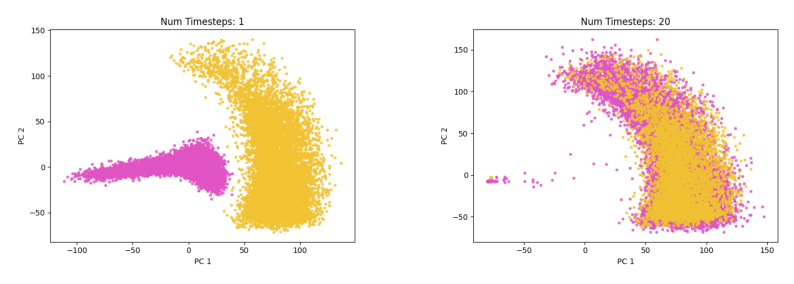

,frechet_distance,frechet_ratio
num_timesteps,,
1,12473.69,0.78
20,852.32,0.05


In [9]:
# run generation
generator = torch.Generator().manual_seed(42)
pca_plots = []
fd_rows = []
generated_latents_by_step = {}

for num_timesteps in eval_timesteps:
    gen_latents = generate_activations(num_timesteps, batch_size, generator=generator)
    generated_latents_by_step[num_timesteps] = gen_latents.detach().cpu()
    pca_plot = plot_pca(num_timesteps, batch_size, ref_latents, gen_latents)
    pca_plots.append(pca_plot)
    dist, ratio = compute_fd(ref_latents[:fd_eval_vectors], gen_latents[:fd_eval_vectors], generator=generator)
    fd_rows.append({
        "num_timesteps": num_timesteps,
        "frechet_distance": dist,
        "frechet_ratio": ratio,
    })

# visualize the PCA results
plt.figure(figsize=(5 * len(pca_plots), 5))
for i in range(len(pca_plots)):
    plt.subplot(1, len(pca_plots), i + 1)
    plt.imshow(pca_plots[i])
    plt.axis("off")
plt.show()

# show Frechet Distance summary
fd_df = pd.DataFrame(fd_rows).set_index("num_timesteps").sort_index()
fd_df.round(2)

**Distribution Evaluation: 1D Wasserstein and 1D Frechet Distance Attribution**

For GPT-2 activations, we use two separate diagnostics instead:

1. **1D Wasserstein Distance:** Exact 1D W1 for each hidden dimension, measuring the difference in distributions per dimension.
2. **1D Frechet Distance:** FD computed per dimension, assuming each dimension is an independent 1D Gaussian, to compare mean and variance per dimension.

Keep the original full-covariance FD table above as a continuity baseline; use the metrics below for debugging and model selection.

In [10]:
def _activation_vectors(latents):
    """Return [n, d] activation vectors on CPU float32 from [n, 1, d] or [n, d]."""
    vecs = latents.detach().cpu().float()
    if vecs.ndim == 3:
        vecs = vecs[:, 0, :]
    if vecs.ndim != 2:
        raise ValueError(f"Expected [n, d] or [n, 1, d], got {tuple(vecs.shape)}")
    return vecs


def _align_samples(ref_latents, gen_latents, max_vectors=None):
    ref = _activation_vectors(ref_latents)
    gen = _activation_vectors(gen_latents)
    n = min(ref.shape[0], gen.shape[0])
    if max_vectors is not None:
        n = min(n, int(max_vectors))
    if n < 2:
        raise ValueError("Need at least 2 vectors per set.")
    return ref[:n].contiguous(), gen[:n].contiguous()


def frechet_distance_1d_per_dim(ref_latents, gen_latents, max_vectors=None):
    """Compute 1D Frechet Distance for each dimension, assuming independent 1D Gaussians."""
    ref_raw, gen_raw = _align_samples(ref_latents, gen_latents, max_vectors=max_vectors)
    
    mu_ref = ref_raw.mean(dim=0)
    sigma_ref = ref_raw.std(dim=0, unbiased=False)
    mu_gen = gen_raw.mean(dim=0)
    sigma_gen = gen_raw.std(dim=0, unbiased=False)
    
    fd_1d = (mu_ref - mu_gen).pow(2) + (sigma_ref - sigma_gen).pow(2)
    
    # For noise: standard normal N(0,1)
    mu_noise = torch.zeros_like(mu_ref)
    sigma_noise = torch.ones_like(sigma_ref)
    fd_noise_1d = (mu_ref - mu_noise).pow(2) + (sigma_ref - sigma_noise).pow(2)
    
    fd_ratio_1d = torch.where(fd_noise_1d > 1e-8, fd_1d / fd_noise_1d, torch.tensor(float('inf')))
    
    return fd_1d, fd_ratio_1d


def wasserstein_1d_per_dim(ref_latents, gen_latents, max_vectors=None):
    """Raw attribution score: exact 1D W1 for each dim using equal sample counts."""
    ref_raw, gen_raw = _align_samples(ref_latents, gen_latents, max_vectors=max_vectors)
    ref_sorted = ref_raw.sort(dim=0).values
    gen_sorted = gen_raw.sort(dim=0).values
    w1 = (ref_sorted - gen_sorted).abs().mean(dim=0)

    fd_1d, fd_ratio_1d = frechet_distance_1d_per_dim(ref_latents, gen_latents, max_vectors)

    ref_mean = ref_raw.mean(dim=0)
    gen_mean = gen_raw.mean(dim=0)
    ref_var = ref_raw.var(dim=0, unbiased=False)
    gen_var = gen_raw.var(dim=0, unbiased=False)
    glp_var = var.detach().cpu().float().reshape(-1)

    df = pd.DataFrame({
        "dim": np.arange(ref_raw.shape[1]),
        "wasserstein_1d_raw": w1.numpy(),
        "frechet_distance_1d": fd_1d.numpy(),
        "frechet_distance_1d_ratio": fd_ratio_1d.numpy(),
        "fd_ratio_over_wasserstein": torch.where(w1 > 1e-8, fd_ratio_1d / w1, torch.tensor(float('inf'))).numpy(),
        "ref_mean_raw": ref_mean.numpy(),
        "gen_mean_raw": gen_mean.numpy(),
        "mean_abs_error_raw": (gen_mean - ref_mean).abs().numpy(),
        "ref_var_raw": ref_var.numpy(),
        "gen_var_raw": gen_var.numpy(),
        "var_abs_error_raw": (gen_var - ref_var).abs().numpy(),
        "glp_var": glp_var.numpy(),
    })
    df["glp_var_rank"] = df["glp_var"].rank(method="min", ascending=False).astype(int)
    df["wasserstein_rank"] = df["wasserstein_1d_raw"].rank(method="min", ascending=False).astype(int)
    df["frechet_rank"] = df["frechet_distance_1d"].rank(method="min", ascending=False).astype(int)
    df["frechet_ratio_rank"] = df["frechet_distance_1d_ratio"].rank(method="min", ascending=False).astype(int)
    return df.sort_values("wasserstein_1d_raw", ascending=False).reset_index(drop=True)


def plot_raw_wasserstein_attribution(wass_df, top_k=20):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(wass_df["glp_var"], wass_df["frechet_distance_1d_ratio"], s=10, alpha=0.35)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("GLP raw variance")
    ax.set_ylabel("1D Frechet distance ratio")
    ax.set_title("Raw per-dimension attribution (FD ratio vs variance)")
    for _, row in wass_df.sort_values("frechet_distance_1d_ratio", ascending=False).head(top_k).iterrows():
        ax.annotate(int(row["dim"]), (row["glp_var"], row["frechet_distance_1d_ratio"]), fontsize=8)
    plt.tight_layout()
    plt.show()

Evaluation timestep: 20
Raw attribution: top 20 dimensions by 1D Wasserstein
Top-20 W1 dims that are also top-50 GLP variance dims: 16/20


,dim,wasserstein_1d_raw,frechet_distance_1d,frechet_distance_1d_ratio,fd_ratio_over_wasserstein,wasserstein_rank,frechet_rank,frechet_ratio_rank,glp_var_rank,glp_var,ref_var_raw,gen_var_raw,mean_abs_error_raw,var_abs_error_raw
0,580,6.7810,88.397202,0.0555,0.0082,1,1,46,2,1562.174194,1384.305054,2097.083008,3.8274,712.778015
1,268,3.8381,7.696200,0.0010,0.0003,2,2,1024,1,3771.374512,3840.104492,3688.176025,2.4825,151.928207
2,218,2.6071,6.910700,0.0149,0.0057,3,3,736,4,336.776611,326.027100,346.593903,2.5683,20.566799
3,238,2.0585,3.029200,0.0014,0.0007,4,6,1020,3,1184.532959,1196.692749,1082.513672,0.4092,114.179100
4,590,1.9690,4.474200,0.0402,0.0204,5,4,141,8,84.241501,84.096397,99.167099,1.9630,15.070600
5,689,1.7913,3.507600,0.1063,0.0594,6,5,2,11,33.897900,34.564201,41.914799,1.7758,7.350500
6,121,1.5036,2.681800,0.0112,0.0074,7,7,861,6,150.183197,141.877197,157.761307,1.5035,15.884200
7,803,1.4474,2.598300,0.0837,0.0579,8,8,13,10,39.890800,40.921299,50.595200,1.4441,9.673900
8,608,1.1004,0.571700,0.0014,0.0013,9,10,1019,5,216.054794,228.585205,209.312897,0.3840,19.272301
9,373,0.7329,0.747800,0.0036,0.0049,10,9,999,7,115.552498,134.313507,115.972397,0.2736,18.341101



Top 20 dimensions by 1D Frechet Distance Ratio


,dim,wasserstein_1d_raw,frechet_distance_1d,frechet_distance_1d_ratio,fd_ratio_over_wasserstein,wasserstein_rank,frechet_rank,frechet_ratio_rank,glp_var_rank
368,9,0.1688,0.0313,0.6507,3.8537,369,736,1,1024
5,689,1.7913,3.5076,0.1063,0.0594,6,5,2,11
12,526,0.5776,0.3415,0.1058,0.1833,13,13,3,42
14,567,0.4555,0.2281,0.0999,0.2192,15,15,4,228
24,181,0.3950,0.1592,0.0940,0.2381,25,30,5,589
16,981,0.4182,0.1945,0.0937,0.2240,17,20,6,470
28,463,0.3619,0.1486,0.0900,0.2487,29,35,7,627
42,1008,0.3206,0.1540,0.0899,0.2804,43,31,8,848
41,289,0.3293,0.1478,0.0874,0.2655,42,36,9,858
36,90,0.3399,0.1931,0.0869,0.2556,37,21,10,419



Top dimension by fd_ratio / wasserstein: 9


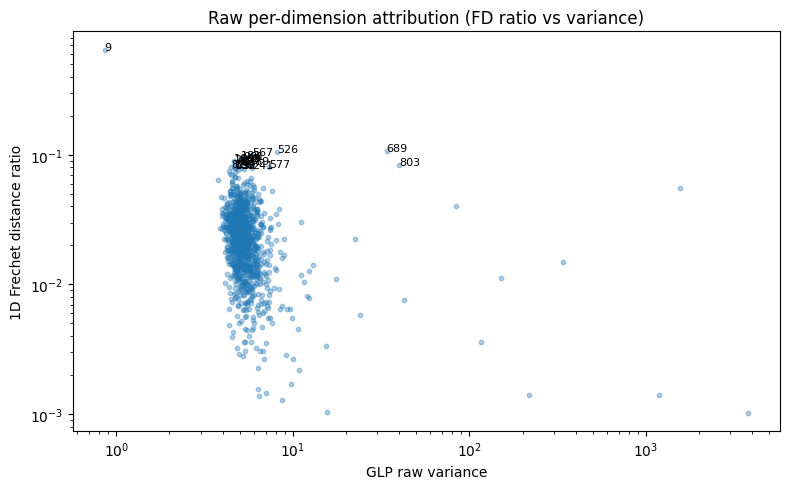

In [11]:
# Choose which generated distribution to evaluate.
eval_quality_timesteps = max(eval_timesteps)
eval_ref = ref_latents[:fd_eval_vectors]
eval_gen = generated_latents_by_step[eval_quality_timesteps][:fd_eval_vectors]

# Attribution metrics
wasserstein_max_vectors = fd_eval_vectors

wass_df = wasserstein_1d_per_dim(
    eval_ref,
    eval_gen,
    max_vectors=wasserstein_max_vectors,
)

top_k = 20
top_wass = wass_df.head(top_k)
top_glp_dims = set(wass_df.sort_values("glp_var", ascending=False).head(50)["dim"])
top_wass_in_top_glp50 = top_wass["dim"].isin(top_glp_dims).sum()

print(f"Evaluation timestep: {eval_quality_timesteps}")
print(f"Raw attribution: top {top_k} dimensions by 1D Wasserstein")
print(f"Top-{top_k} W1 dims that are also top-50 GLP variance dims: {top_wass_in_top_glp50}/{top_k}")
display(top_wass[[
    "dim", "wasserstein_1d_raw", "frechet_distance_1d", "frechet_distance_1d_ratio", "fd_ratio_over_wasserstein", "wasserstein_rank", "frechet_rank", "frechet_ratio_rank", "glp_var_rank",
    "glp_var", "ref_var_raw", "gen_var_raw", "mean_abs_error_raw", "var_abs_error_raw",
]].round(4))

# Top dims by fd_ratio
top_fd_ratio = wass_df.sort_values("frechet_distance_1d_ratio", ascending=False).head(top_k)
print(f"\nTop {top_k} dimensions by 1D Frechet Distance Ratio")
display(top_fd_ratio[[
    "dim", "wasserstein_1d_raw", "frechet_distance_1d", "frechet_distance_1d_ratio", "fd_ratio_over_wasserstein", "wasserstein_rank", "frechet_rank", "frechet_ratio_rank", "glp_var_rank",
]].round(4))

# Top dim by fd_ratio / wasserstein
max_ratio_dim = wass_df.loc[wass_df['fd_ratio_over_wasserstein'].idxmax()]['dim']
print(f"\nTop dimension by fd_ratio / wasserstein: {int(max_ratio_dim)}")

plot_raw_wasserstein_attribution(wass_df, top_k=top_k)

**On-Manifold Steering with GLP (Gemma-2-2B-it)**

Here we use a pre-computed Gemma steering vector and compare:
- normal generation
- steer only
- steer + GLP post-processing

In [ ]:
# If streaming references already loaded Gemma, reuse it.
if "hf_model" not in globals() or "hf_tokenizer" not in globals():
    hf_model, hf_tokenizer = load_model_and_tokenizer(
        model_name=hf_model,
        device=device,
        torch_dtype_name="bfloat16",
    )
else:
    hf_model.to(torch.bfloat16)
    hf_model.eval()
    print("Reusing existing Gemma model/tokenizer from earlier cells.")

if hf_tokenizer.pad_token is None and hf_tokenizer.eos_token is not None:
    hf_tokenizer.pad_token = hf_tokenizer.eos_token
if getattr(hf_model.config, "pad_token_id", None) is None and hf_tokenizer.pad_token_id is not None:
    hf_model.config.pad_token_id = hf_tokenizer.pad_token_id
if getattr(hf_model, "generation_config", None) is not None and hf_model.generation_config.pad_token_id is None:
    hf_model.generation_config.pad_token_id = hf_tokenizer.pad_token_id

import importlib
script_steer = importlib.reload(script_steer)

Reusing existing Gemma model/tokenizer from earlier cells.


In [ ]:
question = "<bos><start_of_turn>user\nWhat is your biggest pet peeve?<end_of_turn>\n<start_of_turn>model\n Response: "
seed = 42
max_new_tokens = 128
temperature = 0.0
alphas = torch.tensor([0, 1, 2, 3, 5, 7, 10], dtype=torch.bfloat16)

glp_u = 0.5
glp_num_timesteps = 5

In [ ]:
layer_name = f"transformer.h.{hf_layer}"

# Load one layer steering vector from a tensor or dict payload.
payload = torch.load(vector_path, map_location="cpu")
steer_vector = payload[hf_layer] if isinstance(payload, dict) else payload

if steer_vector is None:
    raise ValueError(f"Layer {hf_layer} not found in {vector_path}")
if steer_vector.ndim > 1:
    steer_vector = steer_vector.squeeze()
if steer_vector.ndim != 1:
    raise ValueError(f"Expected a 1D steering vector, got shape {tuple(steer_vector.shape)}")
steer_vector = steer_vector.to(device=hf_model.device, dtype=hf_model.dtype)
chat_prompt = question

settings = {
    "No Intervention": (None, None),
    "Steer Only": (script_steer.addition_intervention, None),
    "Steer + GLP": (
        script_steer.addition_intervention,
        script_steer.postprocess_on_manifold_wrapper(
            model,
            u=glp_u,
            num_timesteps=glp_num_timesteps,
            layer_idx=hf_layer,
        ),
    ),
}

results = {}
for setting, (intervention_wrapper, postprocess_fn) in settings.items():
    print(f"Running {setting}...")
    generate_with_intervention = script_steer.generate_with_intervention_wrapper(seed=seed)
    generate_kwargs = {
        "max_new_tokens": max_new_tokens,
        "do_sample": temperature > 0,
        "temperature": temperature,
        "pad_token_id": hf_tokenizer.eos_token_id,
    }

    if intervention_wrapper is None:
        gen_text = generate_with_intervention(
            [chat_prompt] * len(alphas),
            hf_model,
            hf_tokenizer,
            layers=[layer_name],
            intervention_wrapper=None,
            generate_kwargs=generate_kwargs,
        )
    else:
        gen_text = generate_with_intervention(
            [chat_prompt] * len(alphas),
            hf_model,
            hf_tokenizer,
            layers=[layer_name],
            intervention_wrapper=intervention_wrapper,
            intervention_kwargs={
                "w": steer_vector,
                "alphas": alphas.to(device=hf_model.device, dtype=hf_model.dtype),
                "postprocess_fn": postprocess_fn,
            },
            generate_kwargs=generate_kwargs,
        )
    results[setting] = gen_text

Running No Intervention...


LookupError: model.layers.12

In [ ]:
# show results
pd.set_option('display.max_colwidth', None)
results_df = pd.DataFrame(results)
results_df.index = alphas.tolist()
results_df.columns = settings.keys()
results_df

,No Intervention,Steer Only,Steer + GLP
0.0,"\n\nAs a large language model, I don't experience emotions like ""pet peeves"" in the same way humans do. However, there are certain things that can make my responses less effective or frustrating:\n\n* **Ambiguous or unclear prompts:** If you ask me a question that is too broad or lacks context, I might not be able to give you a helpful answer. \n* **Requests for personal information:** I am not designed to provide personal advice or opinions, and I don't have personal experiences or feelings. \n* **Requests that are harmful or unethical:** I am programmed to be helpful and","\n\nAs a large language model, I don't experience emotions like ""pet peeves"" in the same way humans do. However, there are certain things that can make my responses less effective or frustrating:\n\n* **Ambiguous or unclear prompts:** If you ask me a question that is too broad or lacks context, I might not be able to give you a helpful answer. \n* **Requests for personal information:** I am not designed to provide personal advice or opinions, and I don't have personal experiences or feelings. \n* **Requests that are harmful or unethical:** I am programmed to be helpful and","\n\nAs a large language model, I don't experience emotions like ""pet peeves."" However, I can tell you about some things that can make it difficult for me to perform my best:\n\n\n\n * **Incompleteness or ambiguity in prompts:** If you ask me a question that is too broad, vague, or lacks context, I might not be able to give you a helpful answer. \n * ** Asking me to do things I'm not designed to do:** I'm a language model, not a personal assistant or a therapist. I can't provide medical, legal, or financial advice"
1.0,"\n\nAs a large language model, I don't experience emotions like ""pet peeves"" in the same way humans do. However, there are certain things that can make my responses less effective or frustrating:\n\n* **Ambiguous or unclear prompts:** If you ask me a question that is too broad or lacks context, I might not be able to give you a helpful answer. \n* **Requests for personal information:** I am not designed to provide personal advice or opinions, and I don't have personal experiences or feelings. \n* **Requests that are harmful or unethical:** I am programmed to be helpful and","\n\nAs a large language model, I don't have personal feelings or pet peeves like humans do. However, I can tell you that I find it frustrating when people ask me to do things that are outside of my capabilities. For example, I can't:\n\n* **Access real-time information:** I don't have access to the internet or any live data. \n* **Perform actions in the real world:** I can't drive a car, cook a meal, or give you a hug.\n* **Feel emotions:** I'm not capable of experiencing emotions like happiness, sadness, or","\n\n As a large language model, I don't have personal feelings or pet peeves like humans do. \n\n However, I can tell you that I find it frustrating when people ask me to do things that are outside my capabilities. For example, I can't:\n\n * Provide financial, legal, or medical advice.\n * Access real-time information or control physical devices.\n * Express personal opinions or beliefs. \n\n It's important to remember that I'm a tool, and I'm best used for tasks that I can do well, like generating creative text formats, translating languages, and"
2.0,"\n\nAs a large language model, I don't experience emotions like ""pet peeves"" in the same way humans do. However, there are certain things that can make my responses less effective or frustrating:\n\n* **Ambiguous or unclear prompts:** If you ask me a question that is too broad or lacks context, I might not be able to give you a helpful answer. \n* **Requests for personal information:** I am not designed to provide personal advice or opinions, and I don't have personal experiences or feelings. \n* **Requests that are harmful or unethical:** I am programmed to be helpful and","\n\nAs a large 

**Perplexity Sweep for Steering**

This section sweeps steering coefficient, GLP post-process timesteps, and `glp_u` noise rate, then scores the generated continuation text with perplexity under the base GPT-2-medium model.

The baseline is the no-intervention generation for the same prompt and seed. The table below reports mean perplexity, mean change vs baseline, and the best configuration by the smallest perplexity increase or largest reduction. If every setting is worse than baseline, the notebook will call out the least harmful configuration.

In [ ]:
def score_continuation_perplexity(texts, tokenizer, lm_model, batch_size=8, prompt_texts=None):
    """Return per-text perplexity with loss computed only on generated text."""
    lm_model.eval()
    rows = []
    device = next(lm_model.parameters()).device
    if prompt_texts is None:
        prompt_texts = [""] * len(texts)
    elif isinstance(prompt_texts, str):
        prompt_texts = [prompt_texts] * len(texts)
    elif len(prompt_texts) != len(texts):
        raise ValueError("prompt_texts must be None, a string, or the same length as texts.")

    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start:start + batch_size]
        batch_prompts = prompt_texts[start:start + batch_size]
        batch_generated = [
            text[len(prompt):] if prompt and text.startswith(prompt) else text
            for text, prompt in zip(batch_texts, batch_prompts)
        ]
        batch_scored_texts = [prompt + generated for prompt, generated in zip(batch_prompts, batch_generated)]
        prompt_token_counts = [
            len(tokenizer(prompt, add_special_tokens=False)["input_ids"])
            for prompt in batch_prompts
        ]
        enc = tokenizer(
            batch_scored_texts,
            return_tensors="pt",
            padding=True,
            truncation=False,
            add_special_tokens=False,
        ).to(device)

        with torch.no_grad():
            logits = lm_model(**enc).logits.float()

        if logits.shape[1] < 2:
            for text in batch_generated:
                rows.append({
                    "text": text,
                    "num_tokens": 0,
                    "mean_nll": float("nan"),
                    "perplexity": float("nan"),
                })
            continue

        shift_logits = logits[:, :-1, :]
        shift_labels = enc["input_ids"][:, 1:].clone()
        shift_mask = enc["attention_mask"][:, 1:].float()
        shift_labels = shift_labels.masked_fill(shift_mask == 0, -100)
        label_positions = torch.arange(1, enc["input_ids"].shape[1], device=device).unsqueeze(0)
        prompt_lengths = torch.tensor(prompt_token_counts, device=device).unsqueeze(1)
        generated_mask = label_positions >= prompt_lengths
        shift_labels = shift_labels.masked_fill(~generated_mask, -100)

        token_nll = torch.nn.functional.cross_entropy(
            shift_logits.reshape(-1, shift_logits.shape[-1]),
            shift_labels.reshape(-1),
            reduction="none",
            ignore_index=-100,
        ).view_as(shift_labels)

        token_mask = shift_labels.ne(-100).float()
        token_counts = token_mask.sum(dim=1)
        mean_nll = torch.full_like(token_counts, float("nan"), dtype=torch.float32)
        valid = token_counts > 0
        if valid.any():
            mean_nll[valid] = (token_nll * token_mask)[valid].sum(dim=1) / token_counts[valid]

        ppl = torch.exp(mean_nll)
        for text, count, nll_value, ppl_value in zip(batch_generated, token_counts, mean_nll, ppl):
            rows.append({
                "text": text,
                "num_tokens": int(count.item()),
                "mean_nll": float(nll_value.item()) if torch.isfinite(nll_value) else float("nan"),
                "perplexity": float(ppl_value.item()) if torch.isfinite(ppl_value) else float("nan"),
            })

    return pd.DataFrame(rows)


def generate_texts_for_setting(prompt_text, alpha_values, postprocess_fn, seed, max_new_tokens, temperature):
    generate_with_intervention = script_steer.generate_with_intervention_wrapper(seed=seed)
    generate_kwargs = {
        "max_new_tokens": max_new_tokens,
        "do_sample": temperature > 0,
        "temperature": temperature,
        "pad_token_id": hf_tokenizer.eos_token_id,
    }
    if postprocess_fn is None:
        return generate_with_intervention(
            [prompt_text] * len(alpha_values),
            hf_model,
            hf_tokenizer,
            layers=[layer_name],
            intervention_wrapper=script_steer.addition_intervention,
            intervention_kwargs={
                "w": steer_vector,
                "alphas": torch.tensor(alpha_values, device=hf_model.device, dtype=hf_model.dtype),
                "postprocess_fn": lambda x: x,
            },
            generate_kwargs=generate_kwargs,
        )

    return generate_with_intervention(
        [prompt_text] * len(alpha_values),
        hf_model,
        hf_tokenizer,
        layers=[layer_name],
        intervention_wrapper=script_steer.addition_intervention,
        intervention_kwargs={
            "w": steer_vector,
            "alphas": torch.tensor(alpha_values, device=hf_model.device, dtype=hf_model.dtype),
            "postprocess_fn": postprocess_fn,
        },
        generate_kwargs=generate_kwargs,
    )


def summarize_perplexity_sweep(sweep_rows):
    sweep_df = pd.DataFrame(sweep_rows)
    if sweep_df.empty:
        raise RuntimeError("No sweep rows were produced.")

    summary_df = (
        sweep_df
        .groupby(["glp_u", "glp_num_timesteps"], as_index=False)
        .agg(
            baseline_ppl=("baseline_ppl", "first"),
            mean_steer_only_ppl=("steer_only_ppl", "mean"),
            mean_denoised_ppl=("denoised_ppl", "mean"),
            mean_glp_reduction=("ppl_reduction_after_glp", "mean"),
            median_glp_reduction=("ppl_reduction_after_glp", "median"),
            best_glp_reduction=("ppl_reduction_after_glp", "max"),
            best_steer_coeff=("steer_coeff", lambda s: float(s.loc[sweep_df.loc[s.index, "ppl_reduction_after_glp"].idxmax()])),
        )
    )
    summary_df["mean_steer_only_delta_vs_baseline"] = summary_df["mean_steer_only_ppl"] - summary_df["baseline_ppl"]
    summary_df["mean_denoised_delta_vs_baseline"] = summary_df["mean_denoised_ppl"] - summary_df["baseline_ppl"]
    summary_df["mean_glp_reduction_pct"] = 100.0 * summary_df["mean_glp_reduction"] / summary_df["baseline_ppl"]
    summary_df["best_glp_reduction_pct"] = 100.0 * summary_df["best_glp_reduction"] / summary_df["baseline_ppl"]
    return sweep_df, summary_df.sort_values(["mean_glp_reduction", "mean_denoised_ppl"], ascending=[False, True]).reset_index(drop=True)


In [ ]:
from itertools import product
sweep_prompt = chat_prompt if "chat_prompt" in globals() else question
sweep_seed = seed if "seed" in globals() else 42
max_new_tokens = 80
temperature = 0.5

# Keep the sweep small enough to run interactively; extend these lists if you want a wider search.
steer_coeff_grid = [1.0, 3.0, 5.0, 7.0, 10.0]
glp_num_timesteps_grid = [5, 10, 20]
glp_u_grid = [0.20, 0.3, 0.5, 0.7]

generation_kwargs = {
    "max_new_tokens": max_new_tokens,
    "do_sample": temperature > 0,
    "temperature": temperature,
    "pad_token_id": hf_tokenizer.eos_token_id,
}

if hf_tokenizer.pad_token is None and hf_tokenizer.eos_token is not None:
    hf_tokenizer.pad_token = hf_tokenizer.eos_token
if getattr(hf_model.config, "pad_token_id", None) is None and hf_tokenizer.pad_token_id is not None:
    hf_model.config.pad_token_id = hf_tokenizer.pad_token_id
if getattr(hf_model, "generation_config", None) is not None and hf_model.generation_config.pad_token_id is None:
    hf_model.generation_config.pad_token_id = hf_tokenizer.pad_token_id

# Baseline generation with no steering or GLP post-processing.
generate_with_intervention = script_steer.generate_with_intervention_wrapper(seed=sweep_seed)
baseline_text = generate_with_intervention(
    [sweep_prompt],
    hf_model,
    hf_tokenizer,
    layers=[layer_name],
    intervention_wrapper=None,
    generate_kwargs=generation_kwargs,
)[0]
baseline_ppl_df = score_continuation_perplexity([baseline_text], hf_tokenizer, hf_model, batch_size=1, prompt_texts=sweep_prompt)
baseline_ppl = float(baseline_ppl_df.loc[0, "perplexity"])

sweep_rows = []
for glp_u_value, num_timesteps in product(glp_u_grid, glp_num_timesteps_grid):
    postprocess_fn = script_steer.postprocess_on_manifold_wrapper(
        model,
        u=glp_u_value,
        num_timesteps=num_timesteps,
        layer_idx=hf_layer,
    )

    steer_only_texts = generate_texts_for_setting(
        sweep_prompt,
        steer_coeff_grid,
        postprocess_fn=None,
        seed=sweep_seed,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
    )
    denoised_texts = generate_texts_for_setting(
        sweep_prompt,
        steer_coeff_grid,
        postprocess_fn=postprocess_fn,
        seed=sweep_seed,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
    )

    steer_only_ppl_df = score_continuation_perplexity(steer_only_texts, hf_tokenizer, hf_model, batch_size=4, prompt_texts=sweep_prompt)
    denoised_ppl_df = score_continuation_perplexity(denoised_texts, hf_tokenizer, hf_model, batch_size=4, prompt_texts=sweep_prompt)

    for steer_coeff, steer_row, denoise_row, steer_text, denoise_text in zip(
        steer_coeff_grid,
        steer_only_ppl_df.to_dict("records"),
        denoised_ppl_df.to_dict("records"),
        steer_only_texts,
        denoised_texts,
    ):
        steer_only_ppl = float(steer_row["perplexity"])
        denoised_ppl = float(denoise_row["perplexity"])
        sweep_rows.append({
            "steer_coeff": float(steer_coeff),
            "glp_u": float(glp_u_value),
            "glp_num_timesteps": int(num_timesteps),
            "baseline_ppl": baseline_ppl,
            "steer_only_ppl": steer_only_ppl,
            "denoised_ppl": denoised_ppl,
            "ppl_reduction_after_glp": float(steer_only_ppl - denoised_ppl),
            "ppl_reduction_after_glp_pct": float(100.0 * (steer_only_ppl - denoised_ppl) / steer_only_ppl),
            "steer_only_delta_vs_baseline": float(steer_only_ppl - baseline_ppl),
            "denoised_delta_vs_baseline": float(denoised_ppl - baseline_ppl),
            "baseline_to_denoised_reduction": float(baseline_ppl - denoised_ppl),
            "baseline_to_denoised_reduction_pct": float(100.0 * (baseline_ppl - denoised_ppl) / baseline_ppl),
            "steer_only_text": steer_text,
            "denoised_text": denoise_text,
        })

sweep_df, summary_df = summarize_perplexity_sweep(sweep_rows)
best_setup = summary_df.iloc[0]
best_glp_row = sweep_df.sort_values(["ppl_reduction_after_glp", "denoised_ppl"], ascending=[False, True]).iloc[0]
best_denoised_row = sweep_df.sort_values(["denoised_ppl", "ppl_reduction_after_glp"], ascending=[True, False]).iloc[0]

print(f"Baseline perplexity: {baseline_ppl:.3f}")
print("\nAll sweep rows (steer-only vs GLP-denoised):")
display(
    sweep_df.sort_values(
        ["ppl_reduction_after_glp", "denoised_ppl"],
        ascending=[False, True],
    )[[
        "steer_coeff",
        "glp_u",
        "glp_num_timesteps",
        "baseline_ppl",
        "steer_only_ppl",
        "denoised_ppl",
        "ppl_reduction_after_glp",
        "ppl_reduction_after_glp_pct",
        "steer_only_delta_vs_baseline",
        "denoised_delta_vs_baseline",
    ]].round(3)
)

print("\nSummary by GLP noise rate and denoise steps:")
display(summary_df.round(3))

print("\nBest improvement from applying GLP on top of steering:")
print(
    f"steer_coeff={best_glp_row['steer_coeff']:.1f}, glp_u={best_glp_row['glp_u']:.2f}, "
    f"glp_num_timesteps={int(best_glp_row['glp_num_timesteps'])}, "
    f"steer_only_ppl={best_glp_row['steer_only_ppl']:.3f}, "
    f"denoised_ppl={best_glp_row['denoised_ppl']:.3f}, "
    f"reduction={best_glp_row['ppl_reduction_after_glp']:.3f}"
)

if best_glp_row["ppl_reduction_after_glp"] <= 0:
    print("No tested setting reduced perplexity after GLP; the line above is the least harmful configuration.")
print("\nBest absolute denoised perplexity:")
print(
    f"steer_coeff={best_denoised_row['steer_coeff']:.1f}, glp_u={best_denoised_row['glp_u']:.2f}, "
    f"glp_num_timesteps={int(best_denoised_row['glp_num_timesteps'])}, "
    f"denoised_ppl={best_denoised_row['denoised_ppl']:.3f}, "
    f"steer_only_ppl={best_denoised_row['steer_only_ppl']:.3f}"
)

print("\nTop 10 configs by GLP reduction over steer-only:")
display(
    sweep_df.sort_values(["ppl_reduction_after_glp", "denoised_ppl"], ascending=[False, True])
    .head(10)
    [[
        "steer_coeff",
        "glp_u",
        "glp_num_timesteps",
        "steer_only_ppl",
        "denoised_ppl",
        "ppl_reduction_after_glp",
        "ppl_reduction_after_glp_pct",
        "steer_only_delta_vs_baseline",
        "denoised_delta_vs_baseline",
    ]]
    .round(3)
)


The following generation flags are not valid and may be ignored: ['cache_implementation']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['cache_implementation']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['cache_implementation']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['cache_implementation']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['cache_implementation']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['cache_implementation']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['cache_implementation']. Set `TRANSFORMERS_VERBOSITY=info` for more details.

Baseline perplexity: 1.636

All sweep rows (steer-only vs GLP-denoised):


,steer_coeff,glp_u,glp_num_timesteps,baseline_ppl,steer_only_ppl,denoised_ppl,ppl_reduction_after_glp,ppl_reduction_after_glp_pct,steer_only_delta_vs_baseline,denoised_delta_vs_baseline
51,3.0,0.7,10,1.636,4.238,2.793,1.445,34.099,2.602,1.157
56,3.0,0.7,20,1.636,4.238,3.989,0.248,5.860,2.602,2.353
46,3.0,0.7,5,1.636,4.238,4.044,0.194,4.570,2.602,2.408
55,1.0,0.7,20,1.636,1.752,1.775,-0.023,-1.301,0.116,0.139
50,1.0,0.7,10,1.636,1.752,1.806,-0.054,-3.086,0.116,0.170
45,1.0,0.7,5,1.636,1.752,1.821,-0.069,-3.925,0.116,0.185
35,1.0,0.5,10,1.636,1.752,1.938,-0.186,-10.613,0.116,0.302
40,1.0,0.5,20,1.636,1.752,2.195,-0.443,-25.293,0.116,0.559
20,1.0,0.3,10,1.636,1.752,2.310,-0.558,-31.832,0.116,0.674
30,1.0,0.5,5,1.636,1.752,2.697,-0.945,-53.922,0.116,1.061



Summary by GLP noise rate and denoise steps:


,glp_u,glp_num_timesteps,baseline_ppl,mean_steer_only_ppl,mean_denoised_ppl,mean_glp_reduction,median_glp_reduction,best_glp_reduction,best_steer_coeff,mean_steer_only_delta_vs_baseline,mean_denoised_delta_vs_baseline,mean_glp_reduction_pct,best_glp_reduction_pct
0,0.7,20,1.636,13.484,279.517,-266.033,-79.131,0.248,3.0,11.847,277.881,-16260.827,15.179
1,0.7,5,1.636,13.484,355.487,-342.003,-51.239,0.194,3.0,11.847,353.851,-20904.357,11.836
2,0.5,10,1.636,13.484,1792.228,-1778.744,-156.845,-0.186,1.0,11.847,1790.592,-108722.715,-11.365
3,0.5,20,1.636,13.484,2703.033,-2689.550,-239.217,-0.443,1.0,11.847,2701.397,-164394.167,-27.086
4,0.5,5,1.636,13.484,4349.369,-4335.885,-247.233,-0.945,1.0,11.847,4347.733,-265023.624,-57.743
5,0.7,10,1.636,13.484,4580.138,-4566.654,-49.037,1.445,3.0,11.847,4578.502,-279128.977,88.321
6,0.3,20,1.636,13.484,8385.189,-8371.705,-550.942,-1.538,1.0,11.847,8383.553,-511706.239,-94.031
7,0.2,20,1.636,13.484,8423.527,-8410.044,-1634.155,-3.769,1.0,11.847,8421.891,-514049.624,-230.398
8,0.2,10,1.636,13.484,9538.945,-9525.461,-784.560,-2.924,1.0,11.847,9537.309,-582227.619,-178.709
9,0.3,10,1.636,13.484,11423.210,-11409.727,-550.942,-0.558,1.0,11.847,11421.574,-697400.153,-34.087



Best improvement from applying GLP on top of steering:
steer_coeff=3.0, glp_u=0.70, glp_num_timesteps=10, steer_only_ppl=4.238, denoised_ppl=2.793, reduction=1.445

Best absolute denoised perplexity:
steer_coeff=1.0, glp_u=0.70, glp_num_timesteps=20, denoised_ppl=1.775, steer_only_ppl=1.752

Top 10 configs by GLP reduction over steer-only:


,steer_coeff,glp_u,glp_num_timesteps,steer_only_ppl,denoised_ppl,ppl_reduction_after_glp,ppl_reduction_after_glp_pct,steer_only_delta_vs_baseline,denoised_delta_vs_baseline
51,3.0,0.7,10,4.238,2.793,1.445,34.099,2.602,1.157
56,3.0,0.7,20,4.238,3.989,0.248,5.860,2.602,2.353
46,3.0,0.7,5,4.238,4.044,0.194,4.570,2.602,2.408
55,1.0,0.7,20,1.752,1.775,-0.023,-1.301,0.116,0.139
50,1.0,0.7,10,1.752,1.806,-0.054,-3.086,0.116,0.170
45,1.0,0.7,5,1.752,1.821,-0.069,-3.925,0.116,0.185
35,1.0,0.5,10,1.752,1.938,-0.186,-10.613,0.116,0.302
40,1.0,0.5,20,1.752,2.195,-0.443,-25.293,0.116,0.559
20,1.0,0.3,10,1.752,2.310,-0.558,-31.832,0.116,0.674
30,1.0,0.5,5,1.752,2.697,-0.945,-53.922,0.116,1.061
